In [14]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
import joblib
from sklearn.model_selection import train_test_split 
model = joblib.load("../models/random_forest_tuned.pkl")
preprocessor = joblib.load("../models/preprocessor.pkl")
X = pd.read_csv("../data/X_cleaned.csv")
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [18]:
X_test_processed = preprocessor.transform(X_test)

In [19]:
feature_names = preprocessor.get_feature_names_out()
X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
X_test_processed.head(10)

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__tenure_group_0-1yr,cat__tenure_group_1-2yr,cat__tenure_group_2-4yr,cat__tenure_group_4-6yr,cat__tenure_group_nan,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__num_services
185,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,24.80,24.80,0.0
2715,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,41.0,25.25,996.45,0.0
3825,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,52.0,19.35,1031.70,0.0
1807,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,76.35,76.35,1.0
132,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,67.0,50.55,3260.10,1.0
1263,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,68.0,89.60,6127.60,2.0
3732,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,23.0,77.15,1759.40,4.0
1672,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,72.0,72.10,5016.65,4.0
811,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,70.0,104.00,7250.15,4.0
2526,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,19.40,19.40,0.0


In [20]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)
shap_values

array([[[ 0.00478652, -0.00478652],
        [ 0.00568428, -0.00568428],
        [ 0.00619261, -0.00619261],
        ...,
        [ 0.02664677, -0.02664677],
        [-0.04447161,  0.04447161],
        [ 0.00011099, -0.00011099]],

       [[ 0.00282684, -0.00282684],
        [ 0.00271267, -0.00271267],
        [-0.00053387,  0.00053387],
        ...,
        [ 0.03894886, -0.03894886],
        [ 0.02920603, -0.02920603],
        [ 0.00360044, -0.00360044]],

       [[ 0.00174681, -0.00174681],
        [ 0.00154849, -0.00154849],
        [ 0.00381996, -0.00381996],
        ...,
        [ 0.01796429, -0.01796429],
        [ 0.00722081, -0.00722081],
        [ 0.00104818, -0.00104818]],

       ...,

       [[ 0.0043225 , -0.0043225 ],
        [ 0.00597797, -0.00597797],
        [ 0.00484677, -0.00484677],
        ...,
        [ 0.02924671, -0.02924671],
        [ 0.00407384, -0.00407384],
        [ 0.00296318, -0.00296318]],

       [[ 0.00229658, -0.00229658],
        [ 0.00146623, -0.00

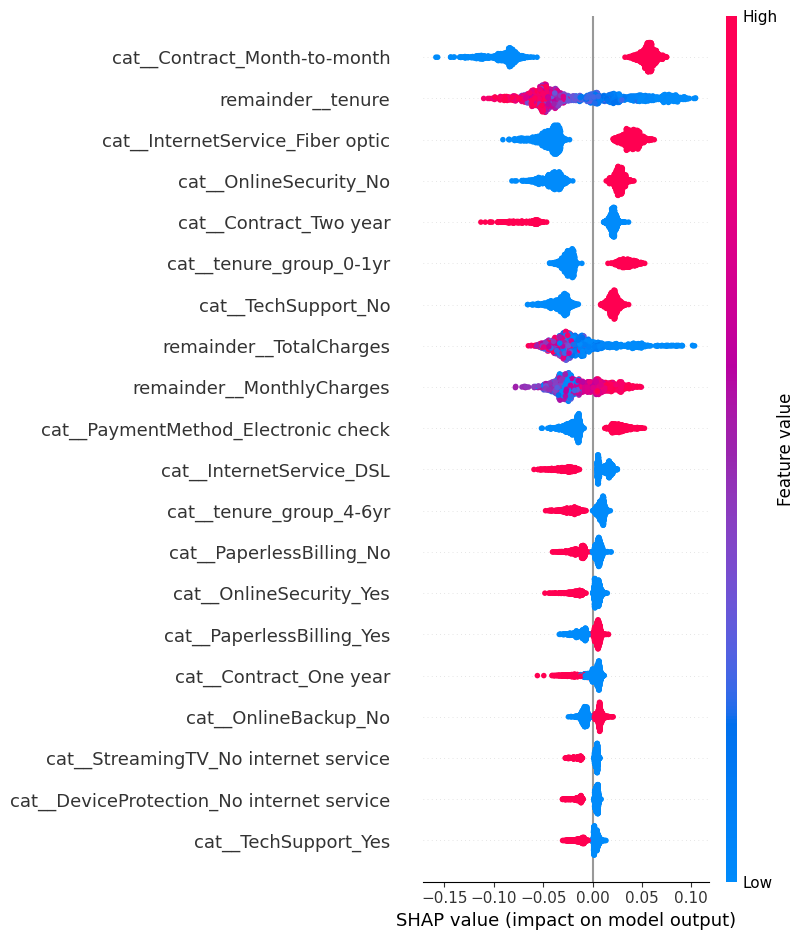

In [22]:
shap.summary_plot(shap_values[:,:,1], X_test_processed)

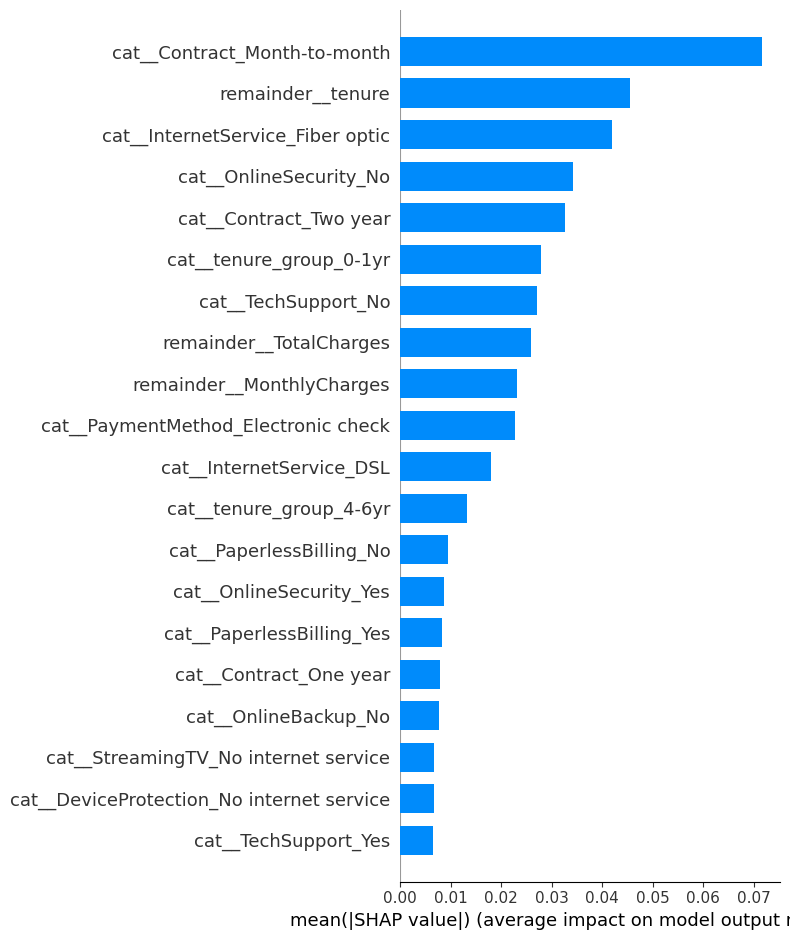

In [23]:
shap.summary_plot(
    shap_values[:,:,1], 
    X_test_processed, 
    plot_type="bar"
)

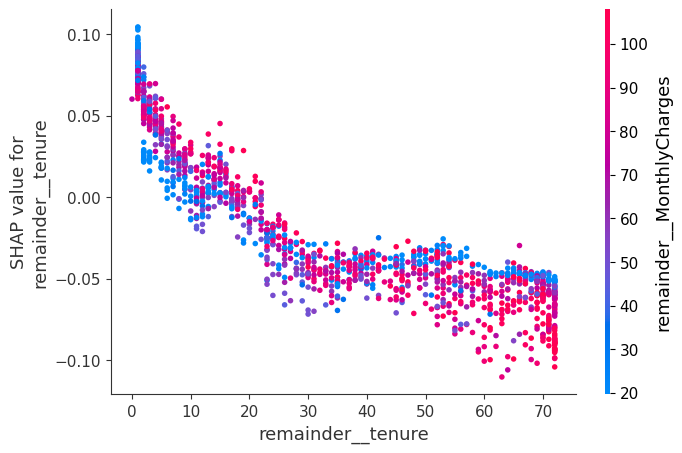

In [26]:
shap.dependence_plot(
    "remainder__tenure",
    shap_values[:,:,1],
    X_test_processed
)  